In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns

In [2]:
data_folder = 'data'

all_csv_paths = []
for dirpath, dirnames, filenames in os.walk(data_folder):
    for filename in filenames:
        if filename.endswith('.csv'):
            all_csv_paths.append((os.path.join(dirpath, filename), filename))

In [3]:
def make_df_list(csv_paths, keyword):
    dfs = []
    for full_path, filename in csv_paths:
        if keyword in filename:
            df = pd.read_csv(full_path)

            if 'running' in filename:
                df['activity_label'] = 0
            
            elif 'rowing' in filename:
                df['activity_label'] = 1

            elif 'jumpingjacks' in filename:
                df['activity_label'] = 2

            elif 'lifting' in filename:
                df['activity_label'] = 3

            dfs.append(df)
    return dfs

In [4]:
dfs_20Hz_hand = make_df_list(all_csv_paths, '20Hz-hand')
dfs_20Hz_pocket = make_df_list(all_csv_paths, '20Hz-pocket')
dfs_100Hz_hand = make_df_list(all_csv_paths, '100Hz-hand')
dfs_100Hz_pocket = make_df_list(all_csv_paths, '100Hz-pocket')

all_df_lists = {
    '20Hz_hand': dfs_20Hz_hand,
    '20Hz_pocket': dfs_20Hz_pocket,
    '100Hz_hand': dfs_100Hz_hand,
    '100Hz_pocket': dfs_100Hz_pocket
}

In [5]:
print(len(dfs_20Hz_hand))
print(len(dfs_20Hz_pocket))
print(len(dfs_100Hz_hand))
print(len(dfs_100Hz_pocket))

212
190
191
190


In [6]:
def radian_or_degree(df):
    for col in df.columns:
        if 'gyro' in col:
            if df[col].abs().max() > 100:
                return 'degree'
    return 'radian'


def degree_to_radian(df):
    for col in df.columns:
        if 'gyro' in col:
            df[col] = np.deg2rad(df[col])
    return df

In [7]:
for key, dfs in all_df_lists.items():
    for i, df in enumerate(dfs):
        dfs[i] = df.dropna().reset_index(drop=True)

for dfs in all_df_lists.values():
    for df in dfs:
        if radian_or_degree(df) == 'degree':
            df = degree_to_radian(df)

In [8]:
for df in dfs_20Hz_hand:
    if radian_or_degree(df) == 'degree':
        print('still degree')

print('everything checked')

everything checked


In [9]:
dfs_20Hz_hand[0].head()

,id,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,activity_label
0,1,1.778591e+09,-6.207352,1.385513,-1.728902,-0.395213,0.096939,2.800580,2
1,2,1.778591e+09,-3.385806,-0.283595,1.610046,-3.393400,-4.149738,4.316984,2
2,3,1.778591e+09,-2.509397,-1.178308,1.921707,0.048470,-4.837366,5.885586,2
3,4,1.778591e+09,-2.469859,-1.844097,0.382194,5.854693,-0.355798,8.094945,2
4,5,1.778591e+09,-2.305365,-2.075951,0.216967,5.471198,0.165116,8.841695,2


Standardizations

In [10]:
scaler = StandardScaler()

scaled_dfs_20Hz_hand = []
scaled_dfs_20Hz_pocket = []
scaled_dfs_100Hz_hand = []
scaled_dfs_100Hz_pocket = []

all_scaled_df_lists = {
    '20Hz_hand': scaled_dfs_20Hz_hand,
    '20Hz_pocket': scaled_dfs_20Hz_pocket,
    '100Hz_hand': scaled_dfs_100Hz_hand,
    '100Hz_pocket': scaled_dfs_100Hz_pocket
}

cols_to_scale = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for key, dfs in all_df_lists.items():
    for df in dfs:
        scaler.fit(df[cols_to_scale])
        scaled_tmp = scaler.transform(df[cols_to_scale])
        scaled_df = df.copy()
        scaled_df[cols_to_scale] = scaled_tmp
        all_scaled_df_lists[key].append(scaled_df)

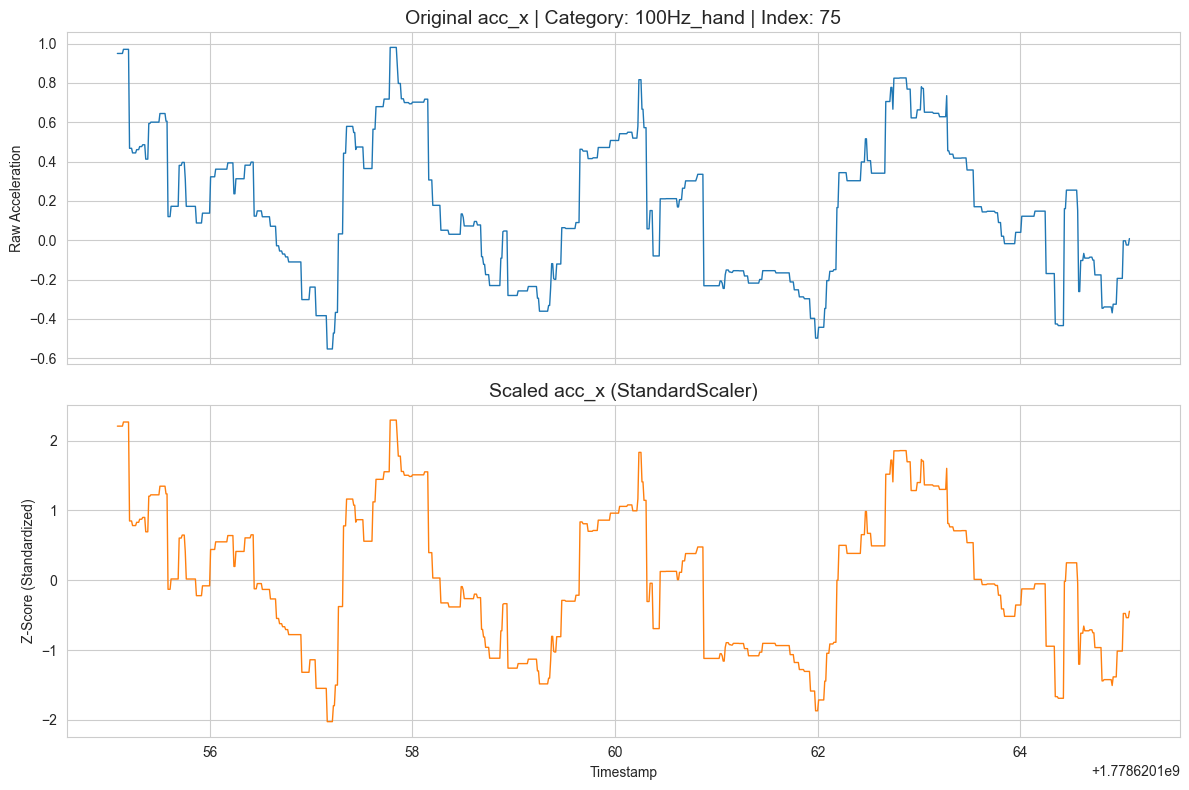

In [11]:
import random
import matplotlib.pyplot as plt

random_key = random.choice(list(all_df_lists.keys()))
random_idx = random.randrange(len(all_df_lists[random_key]))

df_original = all_df_lists[random_key][random_idx]
df_scaled = all_scaled_df_lists[random_key][random_idx]

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Original Data
ax1.plot(df_original['timestamp'], df_original['acc_x'], color='#1f77b4', linewidth=1)
ax1.set_title(f'Original acc_x | Category: {random_key} | Index: {random_idx}', fontsize=14)
ax1.set_ylabel('Raw Acceleration')

# Plot Scaled Data
ax2.plot(df_scaled['timestamp'], df_scaled['acc_x'], color='#ff7f0e', linewidth=1)
ax2.set_title(f'Scaled acc_x (StandardScaler)', fontsize=14)
ax2.set_ylabel('Z-Score (Standardized)')
ax2.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

In [12]:
ts_normalized_20Hz_hand = []
ts_normalized_20Hz_pocket = []
ts_normalized_100Hz_hand = []
ts_normalized_100Hz_pocket = []

all_timestamp_normaized_dfs = {
    '20Hz_hand': ts_normalized_20Hz_hand,
    '20Hz_pocket': ts_normalized_20Hz_pocket,
    '100Hz_hand': ts_normalized_100Hz_hand,
    '100Hz_pocket': ts_normalized_100Hz_pocket
}

for key, dfs in all_df_lists.items():
    for df in dfs:
        min_timestamp = df['timestamp'].min()
        df_tmp = df.copy()
        df_tmp['timestamp'] = (df_tmp['timestamp'] - min_timestamp)
        all_timestamp_normaized_dfs[key].append(df_tmp)

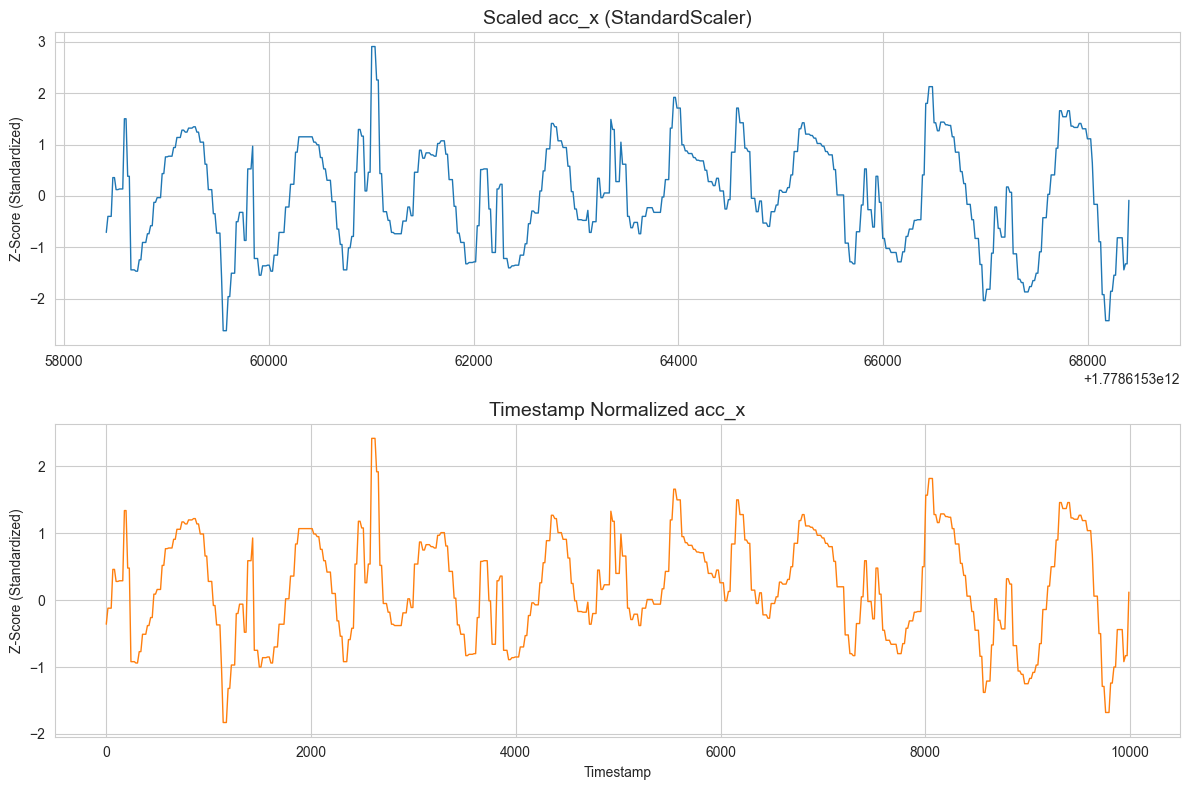

In [13]:
random_key = random.choice(list(all_df_lists.keys()))
random_idx = random.randrange(len(all_df_lists[random_key]))

df_original = all_scaled_df_lists[random_key][random_idx]
df_scaled = all_timestamp_normaized_dfs[random_key][random_idx]

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Original Data
ax1.plot(df_original['timestamp'], df_original['acc_x'], color='#1f77b4', linewidth=1)
ax1.set_title(f'Scaled acc_x (StandardScaler)', fontsize=14)
ax1.set_ylabel('Z-Score (Standardized)')

# Plot Scaled Data
ax2.plot(df_scaled['timestamp'], df_scaled['acc_x'], color='#ff7f0e', linewidth=1)
ax2.set_title(f'Timestamp Normalized acc_x', fontsize=14)
ax2.set_ylabel('Z-Score (Standardized)')
ax2.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

In [14]:
scaler = MinMaxScaler()

normalized_dfs_20Hz_hand = []
normalized_dfs_20Hz_pocket = []
normalized_dfs_100Hz_hand = []
normalized_dfs_100Hz_pocket = []

all_normalized_df_lists = {
    '20Hz_hand': normalized_dfs_20Hz_hand,
    '20Hz_pocket': normalized_dfs_20Hz_pocket,
    '100Hz_hand': normalized_dfs_100Hz_hand,
    '100Hz_pocket': normalized_dfs_100Hz_pocket
}

cols_to_scale = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for key, dfs in all_timestamp_normaized_dfs.items():
    for df in dfs:
        scaler.fit(df[cols_to_scale])
        normalized_tmp = scaler.transform(df[cols_to_scale])
        normalized_df = df.copy()
        normalized_df[cols_to_scale] = normalized_tmp
        all_normalized_df_lists[key].append(normalized_df)

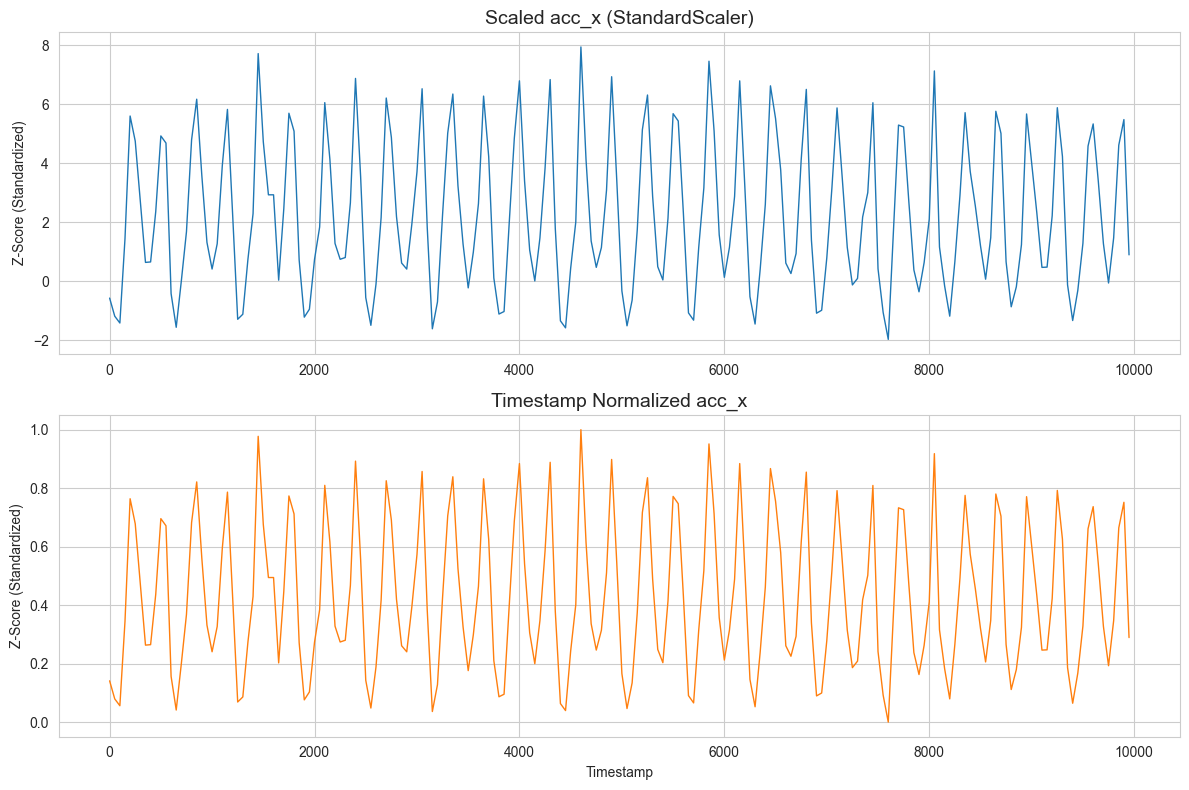

In [15]:
random_key = random.choice(list(all_df_lists.keys()))
random_idx = random.randrange(len(all_df_lists[random_key]))

df_original = all_timestamp_normaized_dfs[random_key][random_idx]
df_scaled = all_normalized_df_lists[random_key][random_idx]

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Original Data
ax1.plot(df_original['timestamp'], df_original['acc_x'], color='#1f77b4', linewidth=1)
ax1.set_title(f'Scaled acc_x (StandardScaler)', fontsize=14)
ax1.set_ylabel('Z-Score (Standardized)')

# Plot Scaled Data
ax2.plot(df_scaled['timestamp'], df_scaled['acc_x'], color='#ff7f0e', linewidth=1)
ax2.set_title(f'Timestamp Normalized acc_x', fontsize=14)
ax2.set_ylabel('Z-Score (Standardized)')
ax2.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

# Feature Extraction

In [16]:
def get_median_amplitude(df, col):
    return df[col].median()


def get_std(df, col):
    return df[col].std()


def get_dominant_frequency(df, col, sampling_rate):
    n = len(df)
    freqs = np.fft.rfftfreq(n, d=1/sampling_rate)
    fft_magnitude = np.abs(np.fft.rfft(df[col]))

    dominant_freq = freqs[1:][np.argmax(fft_magnitude[1:])]
    return dominant_freq

In [17]:
def append_values_to_dict(dict, activity_label, col_features):
    dict['activity_label'].append(activity_label)
    for feature_name, feature_value in col_features.items():
        dict[feature_name].append(feature_value)

In [18]:
import copy
dict_template = {'activity_label': [],
                 'acc_x_median': [], 'acc_x_std': [], 'acc_x_dominant_freq': [],
                 'acc_y_median': [], 'acc_y_std': [], 'acc_y_dominant_freq': [],
                 'acc_z_median': [], 'acc_z_std': [], 'acc_z_dominant_freq': [],
                 'gyro_x_median': [], 'gyro_x_std': [], 'gyro_x_dominant_freq': [],
                 'gyro_y_median': [], 'gyro_y_std': [], 'gyro_y_dominant_freq': [],
                 'gyro_z_median': [], 'gyro_z_std': [], 'gyro_z_dominant_freq': []}

features_20Hz_hand_dict = copy.deepcopy(dict_template)
features_20Hz_pocket_dict = copy.deepcopy(dict_template)
features_100Hz_hand_dict = copy.deepcopy(dict_template)
features_100Hz_pocket_dict = copy.deepcopy(dict_template)

cols_to_evaluate = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for key, dfs in all_normalized_df_lists.items():

    for df in dfs:

        activity = df['activity_label'].iloc[0]

        sampling_rate = None
        if '20Hz' in key:
            sampling_rate = 20
        elif '100Hz' in key:
            sampling_rate = 100

        col_features = {}

        for col in cols_to_evaluate:
            median_amplitude = get_median_amplitude(df, col)
            std = get_std(df, col)
            dominant_freq = get_dominant_frequency(df, col, sampling_rate)

            col_features[f'{col}_median'] = median_amplitude
            col_features[f'{col}_std'] = std
            col_features[f'{col}_dominant_freq'] = dominant_freq
        
        match key:
            case '20Hz_hand':
                append_values_to_dict(features_20Hz_hand_dict, activity, col_features)
            
            case '20Hz_pocket':
                append_values_to_dict(features_20Hz_pocket_dict, activity, col_features)
            
            case '100Hz_hand':
                append_values_to_dict(features_100Hz_hand_dict, activity, col_features)

            case '100Hz_pocket':
                append_values_to_dict(features_100Hz_pocket_dict, activity, col_features)

In [19]:
features_20Hz_hand_df = pd.DataFrame(features_20Hz_hand_dict)
features_20Hz_pocket_df = pd.DataFrame(features_20Hz_pocket_dict)
features_100Hz_hand_df = pd.DataFrame(features_100Hz_hand_dict)
features_100Hz_pocket_df = pd.DataFrame(features_100Hz_pocket_dict)

In [20]:
features_20Hz_hand_df.head(20)

,activity_label,acc_x_median,acc_x_std,acc_x_dominant_freq,acc_y_median,acc_y_std,acc_y_dominant_freq,acc_z_median,acc_z_std,acc_z_dominant_freq,gyro_x_median,gyro_x_std,gyro_x_dominant_freq,gyro_y_median,gyro_y_std,gyro_y_dominant_freq,gyro_z_median,gyro_z_std,gyro_z_dominant_freq
0,2,0.409023,0.205361,1.25000,0.435682,0.174436,1.25000,0.530218,0.155825,0.125000,0.520067,0.202716,1.250000,0.450810,0.178421,1.250000,0.455059,0.309248,1.250000
1,2,0.400871,0.194977,1.25000,0.447617,0.198586,1.25000,0.546952,0.188371,1.250000,0.449711,0.215417,1.250000,0.528756,0.187427,2.625000,0.442819,0.312196,1.250000
2,2,0.484451,0.182196,1.25000,0.442929,0.197596,1.25000,0.449546,0.209802,1.250000,0.461769,0.241119,1.250000,0.427027,0.207525,2.500000,0.488056,0.294404,1.250000
3,2,0.420712,0.198789,1.25000,0.397877,0.190461,1.25000,0.359885,0.146887,1.250000,0.468294,0.198086,1.250000,0.443577,0.212933,2.500000,0.433880,0.326648,1.250000
4,2,0.468400,0.184355,1.25000,0.409778,0.179377,1.25000,0.531448,0.207747,1.250000,0.686683,0.202215,1.250000,0.561159,0.199075,1.250000,0.628194,0.318572,1.250000
5,3,0.380041,0.263410,0.75000,0.414672,0.223159,0.75000,0.732706,0.218304,0.750000,0.483123,0.256826,0.750000,0.464716,0.300285,0.750000,0.403207,0.284509,0.750000
6,3,0.517118,0.277895,0.87500,0.459951,0.193882,0.87500,0.633565,0.207923,0.875000,0.509914,0.293094,0.875000,0.524569,0.295243,0.875000,0.524569,0.221867,0.875000
7,3,0.419948,0.287778,0.75000,0.486406,0.255837,0.75000,0.665110,0.206792,0.750000,0.592562,0.265831,0.750000,0.411167,0.339838,0.750000,0.431146,0.264788,0.750000
8,3,0.478751,0.256757,0.75000,0.695814,0.179239,0.75000,0.697958,0.218276,0.750000,0.425957,0.277663,0.750000,0.585213,0.306792,0.750000,0.482428,0.224814,0.750000
9,3,0.431880,0.266523,0.75000,0.531856,0.271025,0.75000,0.670416,0.202798,0.750000,0.444676,0.293330,0.750000,0.537148,0.288903,0.750000,0.443962,0.246402,0.750000


In [21]:
features_100Hz_hand_df.tail()

,activity_label,acc_x_median,acc_x_std,acc_x_dominant_freq,acc_y_median,acc_y_std,acc_y_dominant_freq,acc_z_median,acc_z_std,acc_z_dominant_freq,gyro_x_median,gyro_x_std,gyro_x_dominant_freq,gyro_y_median,gyro_y_std,gyro_y_dominant_freq,gyro_z_median,gyro_z_std,gyro_z_dominant_freq
186,2,0.672719,0.179100,0.999001,0.443209,0.194161,0.999001,0.411540,0.185723,0.999001,0.492426,0.250341,0.999001,0.514936,0.217809,0.999001,0.393491,0.238721,0.999001
187,2,0.604925,0.149656,0.999001,0.429258,0.177499,0.999001,0.503850,0.168328,0.999001,0.500400,0.290743,0.999001,0.615246,0.179001,0.999001,0.567025,0.205651,0.999001
188,2,0.656889,0.134045,0.999001,0.449179,0.168379,0.999001,0.531735,0.181720,0.999001,0.471998,0.306525,0.999001,0.601470,0.193003,0.999001,0.450986,0.209353,0.999001
189,2,0.667887,0.154069,0.999001,0.458165,0.163467,0.999001,0.557640,0.150888,0.999001,0.435625,0.309421,0.999001,0.630340,0.166262,0.999001,0.484103,0.263450,0.999001
190,2,0.628005,0.142646,0.999001,0.335355,0.150336,0.999001,0.490317,0.174743,0.999001,0.425908,0.310534,0.999001,0.615900,0.168784,1.998002,0.434935,0.230777,0.999001


In [22]:
features_100Hz_hand_df['activity_label'].value_counts()

activity_label
2    51
0    50
3    45
1    45
Name: count, dtype: int64

In [23]:
features_20Hz_hand_df.groupby('activity_label').describe()

acc_x_median                                                    \
                      count      mean       std       min       25%       50%   
activity_label                                                                  
0                      72.0  0.602860  0.178786  0.214083  0.450860  0.608736   
1                      45.0  0.399114  0.169447  0.000000  0.326046  0.450293   
2                      50.0  0.539446  0.111691  0.226974  0.469558  0.559282   
3                      45.0  0.468454  0.111823  0.141361  0.399770  0.465112   

                                   acc_x_std            ... gyro_z_std  \
                     75%       max     count      mean  ...        75%   
activity_label                                          ...              
0               0.765303  0.866491      72.0  0.228680  ...   0.260247   
1               0.515459  0.694454      45.0  0.194197  ...   0.191278   
2               0.609534  0.785518      50.0  0.191027  ...   0.299026   
3               0.520848  0.783437      45.0  0.243669  ...   0.252576   

                         gyro_z_dominant_freq                                \
                     max                count      mean       std  min  25%   
activity_label                                                                
0               0.338184                 72.0  1.373793  0.469281  0.1  1.2   
1               0.286325                 45.0  0.782566  0.614844  0.1  0.4   
2               0.359509                 50.0  0.933655  0.366607  0.1  0.8   
3               0.297577                 45.0  0.672475  0.304619  0.1  0.5   

                                      
                50%    75%       max  
activity_label                        
0               1.5  1.625  3.681592  
1               0.6  1.000  2.750000  
2               0.9  1.000  1.900000  
3               0.7  0.750  1.500000  

[4 rows x 144 columns]

<Axes: xlabel='acc_x_median', ylabel='gyro_x_median'>

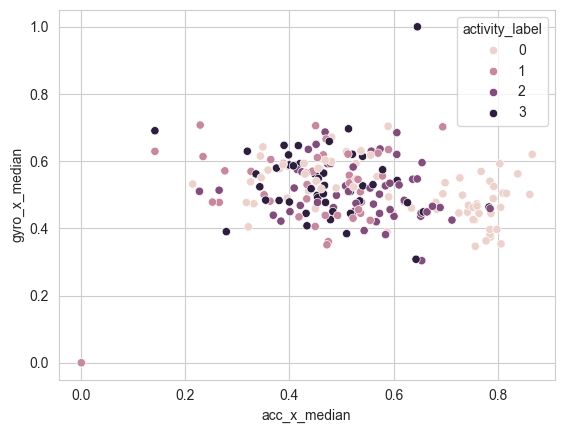

In [24]:
sns.scatterplot(data=features_20Hz_hand_df, x='acc_x_median', y='gyro_x_median', hue='activity_label')

In [25]:
# Split
from sklearn.model_selection import train_test_split

features = features_100Hz_hand_df[list(dict_template.keys())[1:]]
classes = features_100Hz_hand_df['activity_label']

features_train, features_test, classes_train, classes_test = train_test_split(features, classes, test_size=0.2)

In [26]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Train Classifier
selected_kernel = 'rbf'
classifier = svm.SVC(kernel=selected_kernel)
classifier.fit(features_train, classes_train)

# Predict test data
classes_predicted = classifier.predict(features_test)

# Calculate accuracy
accuracy = accuracy_score(classes_test, classes_predicted)
print(f'Accuracy: {accuracy}')

Accuracy: 0.5641025641025641
